Computing CPI (Log-Loss): 100%|██████████| 140/140 [03:56<00:00,  1.69s/feature]


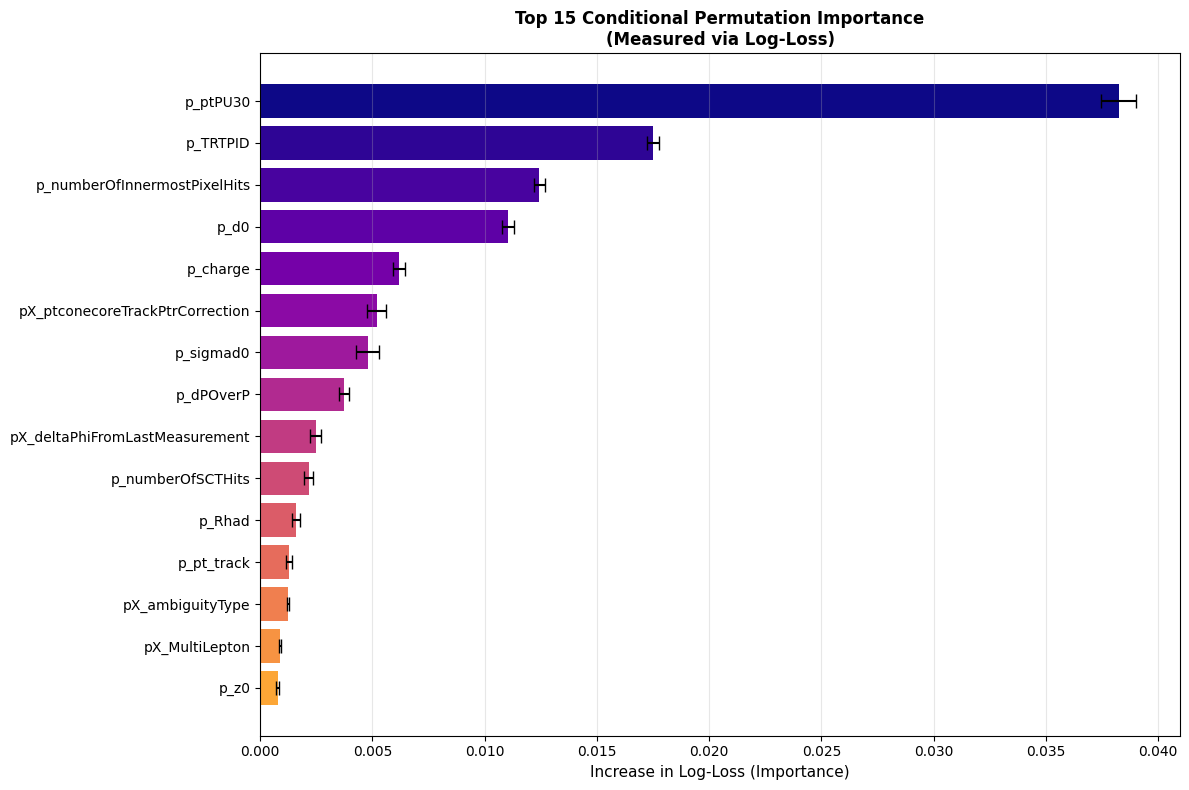

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss  # Added for more granular importance
from xgboost import XGBClassifier, XGBRegressor
from tqdm import tqdm

# --- Data Loading and Initial Prep ---
class_train_data = pd.read_csv('../Data/AppML_InitialProject_train.csv')
target = class_train_data['p_Truth_isElectron']
variables = class_train_data.drop(columns=['p_Truth_isElectron', 'p_Truth_Energy'])
class_test_data = pd.read_csv('../Data/AppML_InitialProject_test_classification.csv')

X_train, X_val, y_train, y_val = train_test_split(
    variables, target, test_size=0.2, random_state=42, stratify=target
)

# --- Train Main Model ---
model = XGBClassifier(
    n_estimators=700,
    max_depth=7,
    learning_rate=0.04,
    subsample=0.6,
    colsample_bytree=0.85,
    gamma=2.4,
    min_child_weight=7,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# --- Updated Conditional Permutation Importance ---
def conditional_permutation_importance(model, X_train, X_val, y_val, features=None, n_repeats=10, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    
    # Use Log-Loss as the baseline (lower is better)
    probs_val = model.predict_proba(X_val)
    baseline_loss = log_loss(y_val, probs_val)
    
    if features is None:
        features = X_train.columns
        
    records = []
    
    for feature in tqdm(features, desc='Computing CPI (Log-Loss)', unit='feature'):
        other_cols = [c for c in X_train.columns if c != feature]

        # Fit regressor to model feature dependencies
        reg = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, n_jobs=-1)
        reg.fit(X_train[other_cols], X_train[feature])

        # Calculate residuals on TRAIN
        preds_train = reg.predict(X_train[other_cols])
        residuals = (X_train[feature] - preds_train).to_numpy()
        
        # Calculate predicted base for VAL
        preds_val_base = reg.predict(X_val[other_cols])
        
        losses = []
        for _ in range(n_repeats):
            # Sample residuals and reconstruct feature
            sampled_resid = rng.choice(residuals, size=len(preds_val_base), replace=True)
            Xc = X_val.copy()
            Xc[feature] = preds_val_base + sampled_resid
            
            # Measure how much the Log-Loss increases (higher increase = more important)
            perm_probs = model.predict_proba(Xc)
            perm_loss = log_loss(y_val, perm_probs)
            losses.append(perm_loss - baseline_loss)
            
        records.append((feature, float(np.mean(losses)), float(np.std(losses))))

    imp_df = pd.DataFrame(records, columns=['feature', 'importance', 'std']).sort_values('importance', ascending=False)
    return imp_df

# Run importance (Note: passed X_train.columns to the 'features' argument)
importance_df = conditional_permutation_importance(
    model, X_train, X_val, y_val, features=X_train.columns, n_repeats=10
)

# --- Visualization ---
top_n = 15
top_features = importance_df.head(top_n)
plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], 
         xerr=top_features['std'], color=plt.cm.plasma(np.linspace(0, 0.8, top_n)), capsize=5)
plt.xlabel('Increase in Log-Loss (Importance)', fontsize=11)
plt.title(f'Top {top_n} Conditional Permutation Importance\n(Measured via Log-Loss)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
# Retrain with top features
top_feature_names = top_features['feature'].tolist()
X_train_top = X_train[top_feature_names]
X_val_top = X_val[top_feature_names]

model_top = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model_top.fit(X_train_top, y_train)
train_score_top = model_top.score(X_train_top, y_train)
val_score_top = model_top.score(X_val_top, y_val)

print(f'Train accuracy with top features: {train_score_top:.4f}')
print(f'Validation accuracy with top features: {val_score_top:.4f}')

Train accuracy with top features: 0.9797
Validation accuracy with top features: 0.9684


In [3]:
# Compute XGBoost parameter count (approx. number of leaf weights) and validation logloss
import numpy as np
from sklearn.metrics import log_loss

param_count = None
val_logloss = None

if 'best_model' in globals():
    try:
        booster = best_model.get_booster()
        trees = booster.get_dump(with_stats=False)
        leaf_count = 0
        for t in trees:
            for line in t.splitlines():
                # XGBoost tree dump lines containing 'leaf=' denote leaf nodes
                if 'leaf=' in line:
                    leaf_count += 1
        param_count = leaf_count  # each leaf has a weight parameter
    except Exception as e:
        print('Could not extract booster dump:', e)

# Validation log loss if X_val_top and y_val exist
if 'best_model' in globals() and 'X_val_top' in globals() and 'y_val' in globals():
    try:
        val_probs = best_model.predict_proba(X_val_top)
        val_logloss = float(log_loss(y_val, val_probs))
    except Exception as e:
        print('Could not compute validation log loss:', e)

print('Approx parameter count (leaf weights):', param_count)
print('Validation log loss (best_model on X_val_top):', val_logloss)

Approx parameter count (leaf weights): None
Validation log loss (best_model on X_val_top): None


In [4]:
# You may need to install this if you haven't: !pip install scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from xgboost import XGBClassifier

# Define the search space
# Note: Unlike Scipy's uniform(loc, scale), skopt uses (low, high)
search_space = {
    'n_estimators': Integer(2300, 3300),
    'max_depth': Integer(5, 20),
    'learning_rate': Real(0.025, 0.075, prior='log-uniform'), # Log-uniform is better for learning rates
    'subsample': Real(0.4, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'gamma': Real(1.5, 4.0),
    'min_child_weight': Integer(2, 20)
}

# Initialize BayesSearchCV
# n_iter=500 in Bayes is often more effective than n_iter=100 in Random Search
bayes_search = BayesSearchCV(
    estimator=XGBClassifier(
        eval_metric='logloss', 
        random_state=42, 
        n_jobs=-1,
        tree_method='hist' # Speeds up training significantly
    ),
    search_spaces=search_space,
    n_iter=100,       # Number of parameter settings sampled
    cv=5,            # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit on the reduced feature set (top 15)
# Assuming X_train_top and X_val_top were created from your CPI results
bayes_search.fit(X_train_top, y_train)

print(f'Best CV score: {bayes_search.best_score_:.4f}')
print(f'Best parameters: {bayes_search.best_params_}')

# Final evaluation
best_model = bayes_search.best_estimator_
val_score_tuned = best_model.score(X_val_top, y_val)
print(f'Validation accuracy after Bayesian tuning: {val_score_tuned:.4f}')

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [5]:
# Compute XGBoost parameter count (approx. number of leaf weights) and validation logloss
import numpy as np
from sklearn.metrics import log_loss

param_count = None
val_logloss = None

if 'best_model' in globals():
    try:
        booster = best_model.get_booster()
        trees = booster.get_dump(with_stats=False)
        leaf_count = 0
        for t in trees:
            for line in t.splitlines():
                # XGBoost tree dump lines containing 'leaf=' denote leaf nodes
                if 'leaf=' in line:
                    leaf_count += 1
        param_count = leaf_count  # each leaf has a weight parameter
    except Exception as e:
        print('Could not extract booster dump:', e)

# Validation log loss if X_val_top and y_val exist
if 'best_model' in globals() and 'X_val_top' in globals() and 'y_val' in globals():
    try:
        val_probs = best_model.predict_proba(X_val_top)
        val_logloss = float(log_loss(y_val, val_probs))
    except Exception as e:
        print('Could not compute validation log loss:', e)

print('Approx parameter count (leaf weights):', param_count)
print('Validation log loss (best_model on X_val_top):', val_logloss)

Approx parameter count (leaf weights): 52004
Validation log loss (best_model on X_val_top): 0.08405192175121656


In [6]:
# Print tuned best_model parameters (for key hyperparameters)
if 'best_model' in globals():
    params = best_model.get_params()
    keys = ['n_estimators','max_depth','learning_rate','subsample','colsample_bytree','gamma','min_child_weight']
    print('Best model hyperparameters:')
    for k in keys:
        print(f"{k}: {params.get(k)}")
else:
    print('best_model not available in notebook globals.')

Best model hyperparameters:
n_estimators: 2969
max_depth: 7
learning_rate: 0.025000000000000005
subsample: 0.672229072778849
colsample_bytree: 0.8185912812478116
gamma: 2.252617462513202
min_child_weight: 11


In [7]:
from pathlib import Path
#Train best model on full training data with top features
X_full_top = variables[top_feature_names]
best_model.fit(X_full_top, target)

# Load test data and extract top features
X_test = class_test_data[top_feature_names]

# Get probability predictions for class 1 (electron)
test_predictions = best_model.predict_proba(X_test)[:, 1]

# Define output paths and filenames
solution_name = "XGBoost2"
name = "BenjaminSiddique"
output_dir = Path('../Classification/Output')
output_dir.mkdir(exist_ok=True)

# Export predictions
predictions_filename = f"Classification_{name}_{solution_name}.csv"
predictions_filepath = output_dir / predictions_filename
with open(predictions_filepath, 'w') as f:
    for idx, pred in enumerate(test_predictions):
        f.write(f"{idx},{pred:.6f}\n")

#Export chosen features
varlist_filename = f"Classification_{name}_{solution_name}_VariableList.csv"
varlist_filepath = output_dir / varlist_filename
with open(varlist_filepath, 'w') as f:
    for var in top_feature_names:
        f.write(f"{var}\n")